In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.applications import VGG19
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

2024-05-31 15:05:45.333966: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-31 15:05:45.334076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-31 15:05:45.487177: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Define the paths to the dataset
data_path = '/kaggle/input/brazilian-sign-language-words-recognition/30 FPS/30 FPS/train'  # Update this to your dataset path

# Function to load images and labels
def load_data(data_path):
    data = []
    labels = []
    for word_folder in os.listdir(data_path):
        if word_folder.lower() == 'formation':  # Ignore the 'formation' class
            continue
        word_folder_path = os.path.join(data_path, word_folder)
        if os.path.isdir(word_folder_path):
            for frame_file in os.listdir(word_folder_path):
                frame_path = os.path.join(word_folder_path, frame_file)
                img = cv2.imread(frame_path)
                if img is not None:
                    img = cv2.resize(img, (64, 64))  # Resize all images to 224x224 for VGG19
                    data.append(img)
                    labels.append(word_folder)
    return np.array(data), np.array(labels)

In [3]:
# Load data
X, y = load_data(data_path)

# Normalize image data
X = X / 255.0

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [4]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Augment data to ensure each class has 1000 samples
augmented_data = []
augmented_labels = []

In [5]:
for label in np.unique(y_encoded):
    class_data = X[y_encoded == label]
    class_labels = y_encoded[y_encoded == label]
    if len(class_data) < 1000:
        augment_iter = datagen.flow(class_data, class_labels, batch_size=1)
        while len(class_data) < 1000:
            augmented_image, augmented_label = next(augment_iter)
            class_data = np.append(class_data, augmented_image, axis=0)
            class_labels = np.append(class_labels, augmented_label, axis=0)
    augmented_data.extend(class_data[:1000])
    augmented_labels.extend(class_labels[:1000])

X_augmented = np.array(augmented_data)
y_augmented = np.array(augmented_labels)

In [6]:
print(X_augmented.shape)
print(y_augmented.shape)

(14000, 64, 64, 3)
(14000,)


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_augmented, y_augmented, test_size=0.2, random_state=42)

In [8]:
# Load the VGG19 model with pre-trained ImageNet weights, excluding the top layer
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(64,64,3))

# Add custom top layers
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(np.unique(y_train)), activation='softmax')(x)

# Define the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the base VGG19 layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Train the model
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
  5/350 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.0560 - loss: 3.0419 

I0000 00:00:1717168290.343971     124 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1717168290.363799     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


347/350 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2311 - loss: 2.2806

W0000 00:00:1717168297.368483     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


350/350 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.2325 - loss: 2.2761 - val_accuracy: 0.5175 - val_loss: 1.3668
Epoch 2/15
  9/350 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4452 - loss: 1.5994

W0000 00:00:1717168301.767339     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5451 - loss: 1.2963 - val_accuracy: 0.7021 - val_loss: 0.8625
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6763 - loss: 0.9552 - val_accuracy: 0.7875 - val_loss: 0.6478
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7341 - loss: 0.7730 - val_accuracy: 0.8161 - val_loss: 0.5429
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7753 - loss: 0.6482 - val_accuracy: 0.8129 - val_loss: 0.5400
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7890 - loss: 0.6181 - val_accuracy: 0.8307 - val_loss: 0.4850
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8026 - loss: 0.5587 - val_accuracy: 0.8486 - val_loss: 0.4460
Epoch 8/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8226 - loss: 0.5119 - val_accuracy: 0.8532 - val_loss: 0.4126
Epoch 9/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8176 - loss: 0.5051 - val_accuracy: 0.835

In [10]:
# Unfreeze the base VGG19 layers and re-train
for layer in base_model.layers:
    layer.trainable = True

# Compile the model again with a lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Continue training
history_fine = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))


Epoch 1/15
  2/350 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.8281 - loss: 0.9510   

W0000 00:00:1717168423.930891     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7987 - loss: 0.6362

W0000 00:00:1717168446.176798     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


350/350 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.7988 - loss: 0.6357 - val_accuracy: 0.8707 - val_loss: 0.3761
Epoch 2/15
  2/350 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9062 - loss: 0.3023

W0000 00:00:1717168448.170942     126 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.8959 - loss: 0.2946 - val_accuracy: 0.9139 - val_loss: 0.2318
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9269 - loss: 0.2048 - val_accuracy: 0.9282 - val_loss: 0.1863
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9485 - loss: 0.1550 - val_accuracy: 0.9296 - val_loss: 0.2017
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9580 - loss: 0.1277 - val_accuracy: 0.9675 - val_loss: 0.0982
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9691 - loss: 0.0945 - val_accuracy: 0.9639 - val_loss: 0.1161
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9706 - loss: 0.0889 - val_accuracy: 0.9693 - val_loss: 0.0834
Epoch 8/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9709 - loss: 0.0924 - val_accuracy: 0.9714 - val_loss: 0.0911
Epoch 9/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9806 - loss: 0.0502 - val_accurac

In [11]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9838 - loss: 0.0608
Test Accuracy: 0.9825000166893005


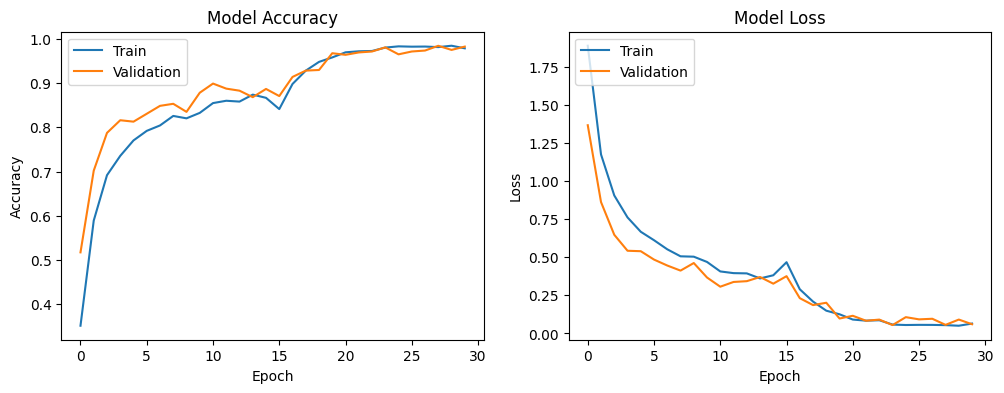

In [12]:
# Learning Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine.history['loss'])
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

13/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

W0000 00:00:1717168769.781997     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


W0000 00:00:1717168771.907827     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


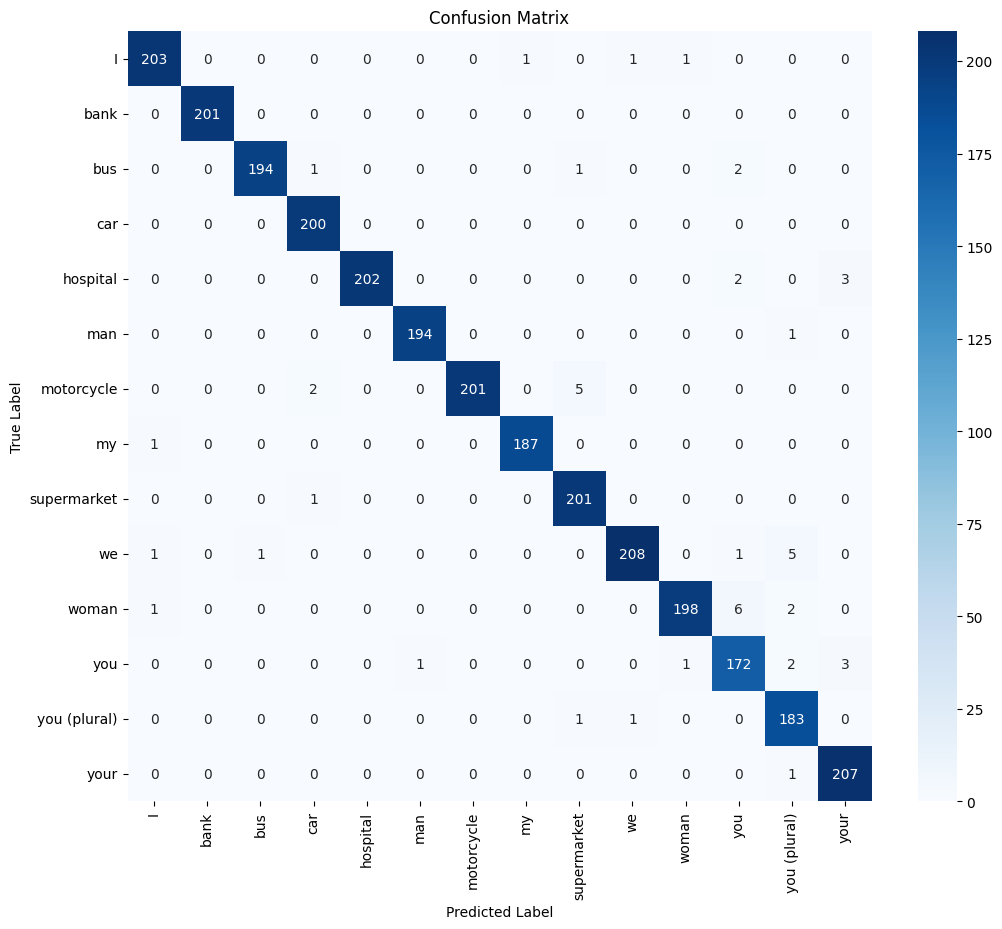

In [13]:
# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [14]:
# Classification Report
class_report = classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_)
print("Classification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           I       0.99      0.99      0.99       206
        bank       1.00      1.00      1.00       201
         bus       0.99      0.98      0.99       198
         car       0.98      1.00      0.99       200
    hospital       1.00      0.98      0.99       207
         man       0.99      0.99      0.99       195
  motorcycle       1.00      0.97      0.98       208
          my       0.99      0.99      0.99       188
 supermarket       0.97      1.00      0.98       202
          we       0.99      0.96      0.98       216
       woman       0.99      0.96      0.97       207
         you       0.94      0.96      0.95       179
you (plural)       0.94      0.99      0.97       185
        your       0.97      1.00      0.98       208

    accuracy                           0.98      2800
   macro avg       0.98      0.98      0.98      2800
weighted avg       0.98      0.98      0.98      2800



In [15]:
model.save('sign_language_recognition_model_22.h5')


In [16]:
test_data_path = '/kaggle/input/brazilian-sign-language-words-recognition/30 FPS/30 FPS/test'  # Update this to your dataset path


In [17]:
# Load test data
X_test2, Y_test2 = load_data(test_data_path)
X_test2 = X_test2 / 255.0
y_test_encoded = label_encoder.transform(Y_test2)


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step


W0000 00:00:1717168845.908067     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


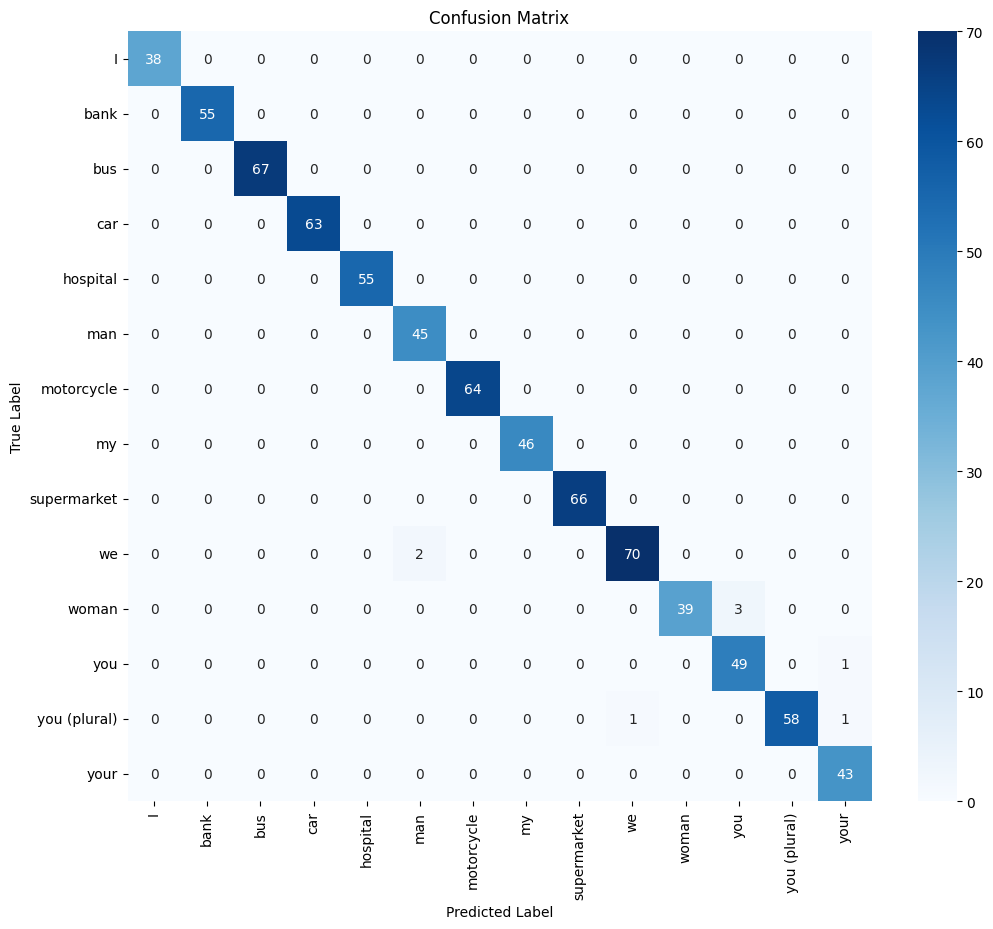

In [18]:
# Confusion Matrix
y_pred = model.predict(X_test2)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test_encoded, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



In [19]:
# Classification Report
class_report = classification_report(y_test_encoded, y_pred_classes, target_names=label_encoder.classes_)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           I       1.00      1.00      1.00        38
        bank       1.00      1.00      1.00        55
         bus       1.00      1.00      1.00        67
         car       1.00      1.00      1.00        63
    hospital       1.00      1.00      1.00        55
         man       0.96      1.00      0.98        45
  motorcycle       1.00      1.00      1.00        64
          my       1.00      1.00      1.00        46
 supermarket       1.00      1.00      1.00        66
          we       0.99      0.97      0.98        72
       woman       1.00      0.93      0.96        42
         you       0.94      0.98      0.96        50
you (plural)       1.00      0.97      0.98        60
        your       0.96      1.00      0.98        43

    accuracy                           0.99       766
   macro avg       0.99      0.99      0.99       766
weighted avg       0.99      0.99      0.99       766

